# Breast Cancer Detection Using Convolutional Neural Network (CNN)

## Project Overview

This project uses a Convolutional Neural Network (CNN) to classify
breast histopathology images into two classes:

- **IDC** — Invasive Ductal Carcinoma
- **Non-IDC** — Tissue without Invasive Ductal Carcinoma


**Dataset → Preprocessing → Data Splitting → Augmentation → CNN → Training → Evaluation → Prediction**

## 1. Project Objective

The main objective of this project is to build a CNN model that can
automatically classify breast histopathology images into two categories:

1. **IDC** — Invasive Ductal Carcinoma (cancerous tissue)
2. **Non-IDC** — Tissue without Invasive Ductal Carcinoma


A Convolutional Neural Network is well suited for image classification
because it can automatically learn important visual patterns from images,
such as edges, shapes, textures, and more complex structures.

### Expected Output

The trained model will receive a breast tissue image as input and predict
whether the image belongs to the **IDC** or **Non-IDC** class.

In [49]:
# Import the required libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Set random seeds for reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:
# Define the path to the dataset

dataset_path = "dataset"

print("Dataset path:", dataset_path)
print("Path exists:", os.path.exists(dataset_path))

Dataset path: dataset
Path exists: True


In [4]:
# Check the contents of the dataset folder

dataset_contents = os.listdir(dataset_path)

print("Items inside dataset folder:")
for item in dataset_contents:
    print("-", item)

Items inside dataset folder:
- 10253
- 10254
- 10255
- 10256
- 10257
- 10258
- 10259
- 10260
- 10261
- 10262
- 10264
- 10268
- 10269
- 10272
- 10273
- 10274
- 10275
- 10276
- 10277
- 10278
- 10279
- 10282
- 10285
- 10286
- 10288
- 10290
- 10291
- 10292
- 10293
- 10295
- 10299
- 10300
- 10301
- 10302
- 10303
- 10304
- 10305
- 10306
- 10307
- 10308
- 12241
- 12242
- 12626
- 12748
- 12749
- 12750
- 12751
- 12752
- 12810
- 12811
- 12817
- 12818
- 12819
- 12820
- 12821
- 12822
- 12823
- 12824
- 12826
- 12867
- 12868
- 12869
- 12870
- 12871
- 12872
- 12873
- 12875
- 12876
- 12877
- 12878
- 12879
- 12880
- 12881
- 12882
- 12883
- 12884
- 12886
- 12890
- 12891
- 12892
- 12893
- 12894
- 12895
- 12896
- 12897
- 12898
- 12900
- 12901
- 12905
- 12906
- 12907
- 12908
- 12909
- 12910
- 12911
- 12929
- 12930
- 12931
- 12932
- 12933
- 12934
- 12935
- 12947
- 12948
- 12949
- 12951
- 12954
- 12955
- 13018
- 13019
- 13020
- 13021
- 13022
- 13023
- 13024
- 13025
- 13106
- 13400
- 13401
- 13402
- 13403
- 1

In [5]:
# Define the path to the actual image dataset

image_dataset_path = os.path.join(
    dataset_path,
    "IDC_regular_ps50_idx5"
)

print("Image dataset path:", image_dataset_path)
print("Path exists:", os.path.exists(image_dataset_path))

Image dataset path: dataset\IDC_regular_ps50_idx5
Path exists: True


In [6]:
# Get all patient/sample folders

patient_folders = [
    folder for folder in os.listdir(image_dataset_path)
    if os.path.isdir(os.path.join(image_dataset_path, folder))
]

print("Number of patient/sample folders:", len(patient_folders))
print("First 10 folders:", patient_folders[:10])

Number of patient/sample folders: 279
First 10 folders: ['10253', '10254', '10255', '10256', '10257', '10258', '10259', '10260', '10261', '10262']


In [7]:
# Check the class folders inside one patient/sample folder

sample_patient = patient_folders[0]
sample_patient_path = os.path.join(image_dataset_path, sample_patient)

class_folders = os.listdir(sample_patient_path)

print("Sample patient folder:", sample_patient)
print("Contents:", class_folders)

Sample patient folder: 10253
Contents: ['0', '1']


In [8]:
# Count images in each class

class_counts = {
    "Non-IDC (0)": 0,
    "IDC (1)": 0
}

for patient in patient_folders:
    patient_path = os.path.join(image_dataset_path, patient)

    for class_name, class_label in [("Non-IDC (0)", "0"), ("IDC (1)", "1")]:
        class_path = os.path.join(patient_path, class_label)

        if os.path.exists(class_path):
            image_files = [
                file for file in os.listdir(class_path)
                if file.lower().endswith((".png", ".jpg", ".jpeg"))
            ]

            class_counts[class_name] += len(image_files)

print("Total images by class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Total images by class:
Non-IDC (0): 198738
IDC (1): 78786


In [9]:
# Define the size of our smaller balanced dataset

IMAGES_PER_CLASS = 1000

print("Images per class:", IMAGES_PER_CLASS)
print("Total images:", IMAGES_PER_CLASS * 2)

Images per class: 1000
Total images: 2000


In [10]:
# Collect image paths for each class

non_idc_paths = []
idc_paths = []

for patient in patient_folders:
    patient_path = os.path.join(image_dataset_path, patient)

    # Class 0: Non-IDC
    non_idc_folder = os.path.join(patient_path, "0")
    if os.path.exists(non_idc_folder):
        for file in os.listdir(non_idc_folder):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                non_idc_paths.append(os.path.join(non_idc_folder, file))

    # Class 1: IDC
    idc_folder = os.path.join(patient_path, "1")
    if os.path.exists(idc_folder):
        for file in os.listdir(idc_folder):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                idc_paths.append(os.path.join(idc_folder, file))

print("Non-IDC image paths:", len(non_idc_paths))
print("IDC image paths:", len(idc_paths))

Non-IDC image paths: 198738
IDC image paths: 78786


In [11]:
# Randomly select images from each class

random.seed(SEED)

selected_non_idc = random.sample(non_idc_paths, IMAGES_PER_CLASS)
selected_idc = random.sample(idc_paths, IMAGES_PER_CLASS)

print("Selected Non-IDC images:", len(selected_non_idc))
print("Selected IDC images:", len(selected_idc))
print("Total selected images:", len(selected_non_idc) + len(selected_idc))

Selected Non-IDC images: 1000
Selected IDC images: 1000
Total selected images: 2000


In [12]:
# Combine the selected image paths and create their labels

image_paths = selected_non_idc + selected_idc

labels = (
    [0] * len(selected_non_idc) +
    [1] * len(selected_idc)
)

print("Total image paths:", len(image_paths))
print("Total labels:", len(labels))
print("Non-IDC labels:", labels.count(0))
print("IDC labels:", labels.count(1))

Total image paths: 2000
Total labels: 2000
Non-IDC labels: 1000
IDC labels: 1000


In [13]:
# Shuffle image paths and labels together

combined = list(zip(image_paths, labels))

random.seed(SEED)
random.shuffle(combined)

image_paths, labels = zip(*combined)

image_paths = list(image_paths)
labels = list(labels)

print("Dataset shuffled successfully.")
print("Total images:", len(image_paths))

Dataset shuffled successfully.
Total images: 2000


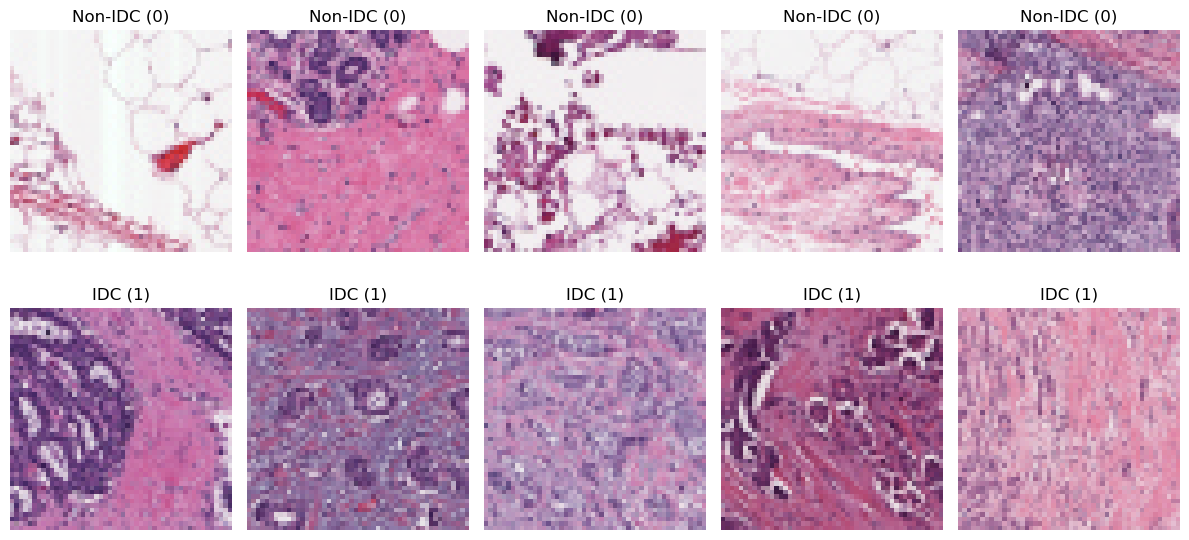

In [14]:
# Display sample images from both classes

plt.figure(figsize=(12, 6))

# Display 5 Non-IDC images
for i in range(5):
    image = Image.open(selected_non_idc[i])

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title("Non-IDC (0)")
    plt.axis("off")

# Display 5 IDC images
for i in range(5):
    image = Image.open(selected_idc[i])

    plt.subplot(2, 5, i + 6)
    plt.imshow(image)
    plt.title("IDC (1)")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Check the dimensions of the selected images

image_sizes = []

for image_path in image_paths:
    with Image.open(image_path) as image:
        image_sizes.append(image.size)

unique_sizes = set(image_sizes)

print("Number of images checked:", len(image_sizes))
print("Number of different image sizes:", len(unique_sizes))
print("Image sizes:", unique_sizes)

Number of images checked: 2000
Number of different image sizes: 13
Image sizes: {(50, 27), (50, 1), (50, 42), (50, 26), (50, 29), (50, 38), (50, 2), (50, 37), (50, 50), (50, 34), (50, 8), (50, 14), (50, 43)}


In [16]:
# Check the image modes

image_modes = {}

for image_path in image_paths:
    with Image.open(image_path) as image:
        mode = image.mode
        image_modes[mode] = image_modes.get(mode, 0) + 1

print("Image modes:")
for mode, count in image_modes.items():
    print(f"{mode}: {count}")

Image modes:
RGB: 2000


In [17]:
# Define the fixed image size for the CNN

IMG_SIZE = 50

print("Target image size:", IMG_SIZE, "×", IMG_SIZE)
print("Color channels: 3 (RGB)")

Target image size: 50 × 50
Color channels: 3 (RGB)


In [18]:
# Load and resize all selected images

X = []
y = []

for image_path, label in zip(image_paths, labels):

    # Open the image
    image = Image.open(image_path)

    # Make sure the image is RGB
    image = image.convert("RGB")

    # Resize to 50 × 50
    image = image.resize((IMG_SIZE, IMG_SIZE))

    # Convert the image to a NumPy array
    image_array = np.array(image)

    # Store the image and its label
    X.append(image_array)
    y.append(label)

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (2000, 50, 50, 3)
Labels shape: (2000,)


In [19]:
# Normalize pixel values to the range 0–1

X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Images shape:", X.shape)

Minimum pixel value: 0.007843138
Maximum pixel value: 1.0
Images shape: (2000, 50, 50, 3)


In [20]:
# Check the class labels

unique_labels, label_counts = np.unique(y, return_counts=True)

print("Unique labels:", unique_labels)

for label, count in zip(unique_labels, label_counts):
    if label == 0:
        class_name = "Non-IDC"
    else:
        class_name = "IDC"

    print(f"Label {label} ({class_name}): {count} images")

Unique labels: [0 1]
Label 0 (Non-IDC): 1000 images
Label 1 (IDC): 1000 images


In [21]:
# Split the dataset into training and temporary sets
# 70% training, 30% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Split the temporary set equally into validation and testing
# 15% validation, 15% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (1400, 50, 50, 3) (1400,)
Validation set: (300, 50, 50, 3) (300,)
Testing set: (300, 50, 50, 3) (300,)


In [22]:
# Check class distribution in each dataset split

print("Training set:")
print("Non-IDC (0):", np.sum(y_train == 0))
print("IDC (1):", np.sum(y_train == 1))

print("\nValidation set:")
print("Non-IDC (0):", np.sum(y_val == 0))
print("IDC (1):", np.sum(y_val == 1))

print("\nTesting set:")
print("Non-IDC (0):", np.sum(y_test == 0))
print("IDC (1):", np.sum(y_test == 1))


Training set:
Non-IDC (0): 700
IDC (1): 700

Validation set:
Non-IDC (0): 150
IDC (1): 150

Testing set:
Non-IDC (0): 150
IDC (1): 150


In [23]:
# Create data augmentation for training images only

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [24]:
# Create a generator for the training data

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True,
    seed=SEED
)

print("Training data generator created successfully.")
print("Batch size:", 32)

Training data generator created successfully.
Batch size: 32


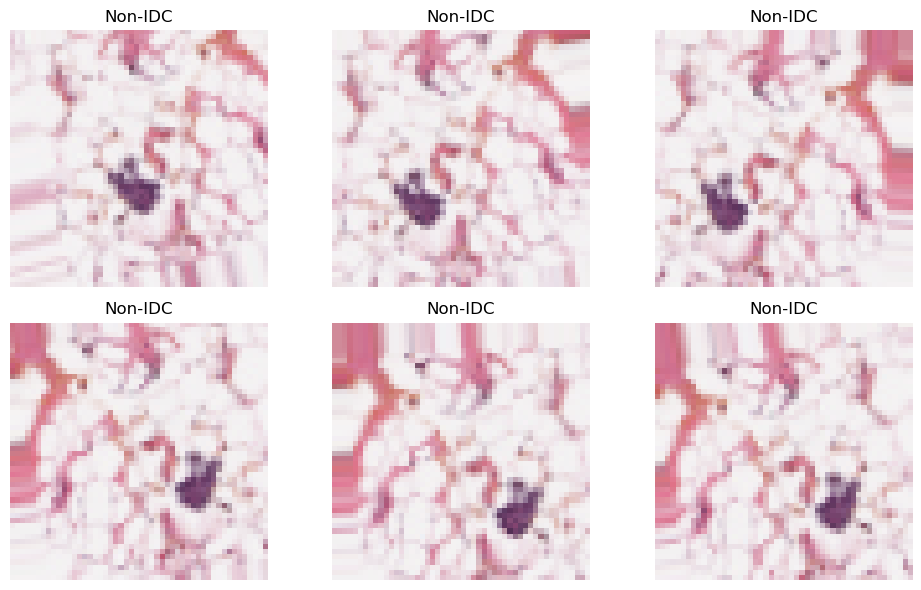

In [27]:
# Display augmented versions of one training image

sample_image = X_train[0]
sample_label = y_train[0]

plt.figure(figsize=(10, 6))

for i in range(6):

    # Generate one augmented batch
    augmented_batch, _ = next(
        train_datagen.flow(
            np.expand_dims(sample_image, axis=0),
            np.array([sample_label]),
            batch_size=1,
            shuffle=False
        )
    )

    # Get the single image from the batch
    augmented_image = augmented_batch[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.title("IDC" if sample_label == 1 else "Non-IDC")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Build the Convolutional Neural Network (CNN)

model = models.Sequential([
    
    # Input layer
    layers.Input(shape=(50, 50, 3)),
    
    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Convert feature maps into a one-dimensional vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(128, activation="relu"),
    
    # Dropout to reduce overfitting
    layers.Dropout(0.5),
    
    # Output layer for binary classification
    layers.Dense(1, activation="sigmoid")
])

print("CNN model created successfully.")

CNN model created successfully.


In [29]:
# Display the CNN architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [32]:
# Define training parameters

EPOCHS = 15
BATCH_SIZE = 32

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Epochs: 15
Batch size: 32


In [33]:
# Train the CNN model

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=(X_val, y_val)
)

print("Training completed successfully.")

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5064 - loss: 0.6938 - val_accuracy: 0.5033 - val_loss: 0.6844
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6529 - loss: 0.6357 - val_accuracy: 0.7367 - val_loss: 0.5504
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7129 - loss: 0.5764 - val_accuracy: 0.7733 - val_loss: 0.5053
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7593 - loss: 0.5511 - val_accuracy: 0.7567 - val_loss: 0.5189
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7564 - loss: 0.5170 - val_accuracy: 0.7233 - val_loss: 0.5395
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7421 - loss: 0.5412 - val_accuracy: 0.7767 - val_loss: 0.5013
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7564 - loss: 0.5136 - val_accuracy: 0.7667 - val_loss: 0.5302
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7786 - loss: 0.4956 - val_accuracy: 0.7633 - v

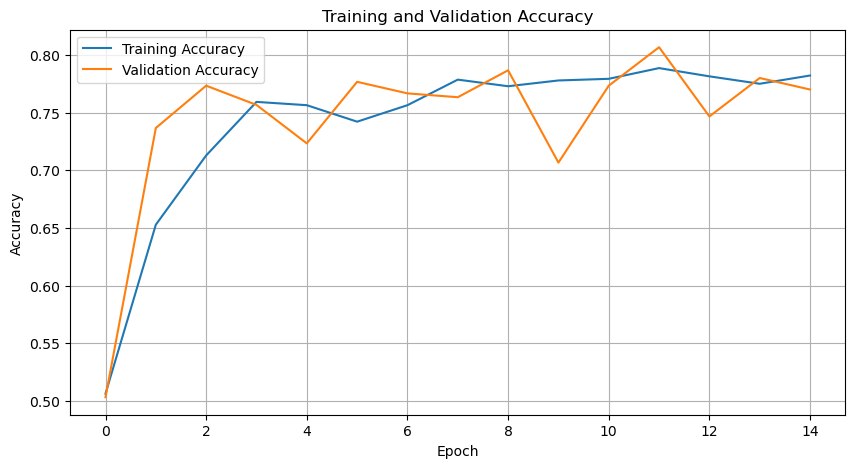

In [34]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

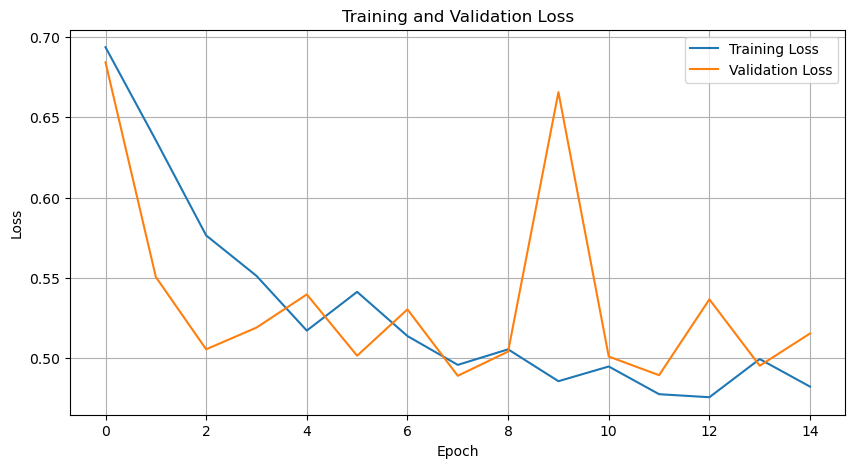

In [35]:
# Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
# Evaluate the trained CNN on the unseen test set

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7667 - loss: 0.4850

Test Loss: 0.4850
Test Accuracy: 0.7667
Test Accuracy: 76.67%


In [37]:
# Generate prediction probabilities for the test images

y_prob = model.predict(X_test)

# Convert probabilities into class predictions
y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Prediction probabilities shape:", y_prob.shape)
print("Predicted labels shape:", y_pred.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction probabilities shape: (300, 1)
Predicted labels shape: (300,)


In [38]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 96  54]
 [ 16 134]]


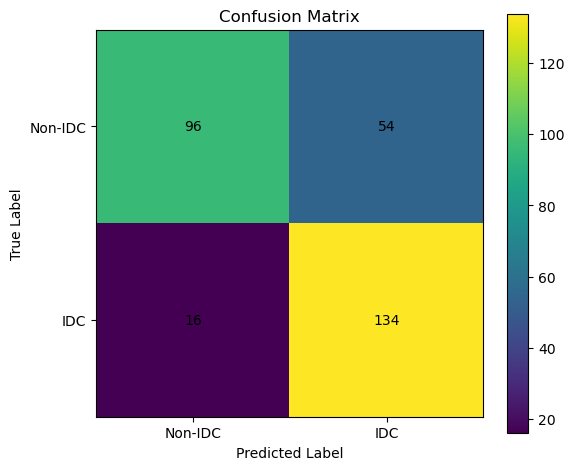

In [39]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Non-IDC", "IDC"])
plt.yticks([0, 1], ["Non-IDC", "IDC"])

# Add numbers to the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.tight_layout()
plt.show()

In [40]:
# Generate the classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Non-IDC", "IDC"]
)

print(report)

              precision    recall  f1-score   support

     Non-IDC       0.86      0.64      0.73       150
         IDC       0.71      0.89      0.79       150

    accuracy                           0.77       300
   macro avg       0.78      0.77      0.76       300
weighted avg       0.78      0.77      0.76       300



In [43]:
# Calculate evaluation metrics

# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-score:  {f1:.4f} ({f1 * 100:.2f}%)")

Accuracy:  0.7667 (76.67%)
Precision: 0.7128 (71.28%)
Recall:    0.8933 (89.33%)
F1-score:  0.7929 (79.29%)


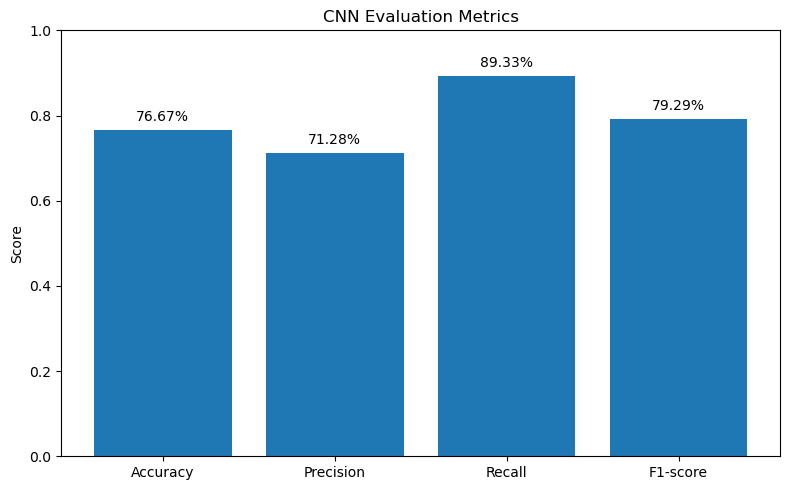

In [44]:
# Visualize the main evaluation metrics

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(metrics.keys(), metrics.values())

plt.title("CNN Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

# Display percentage values above the bars
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f"{value * 100:.2f}%", 
             ha="center")

plt.tight_layout()
plt.show()

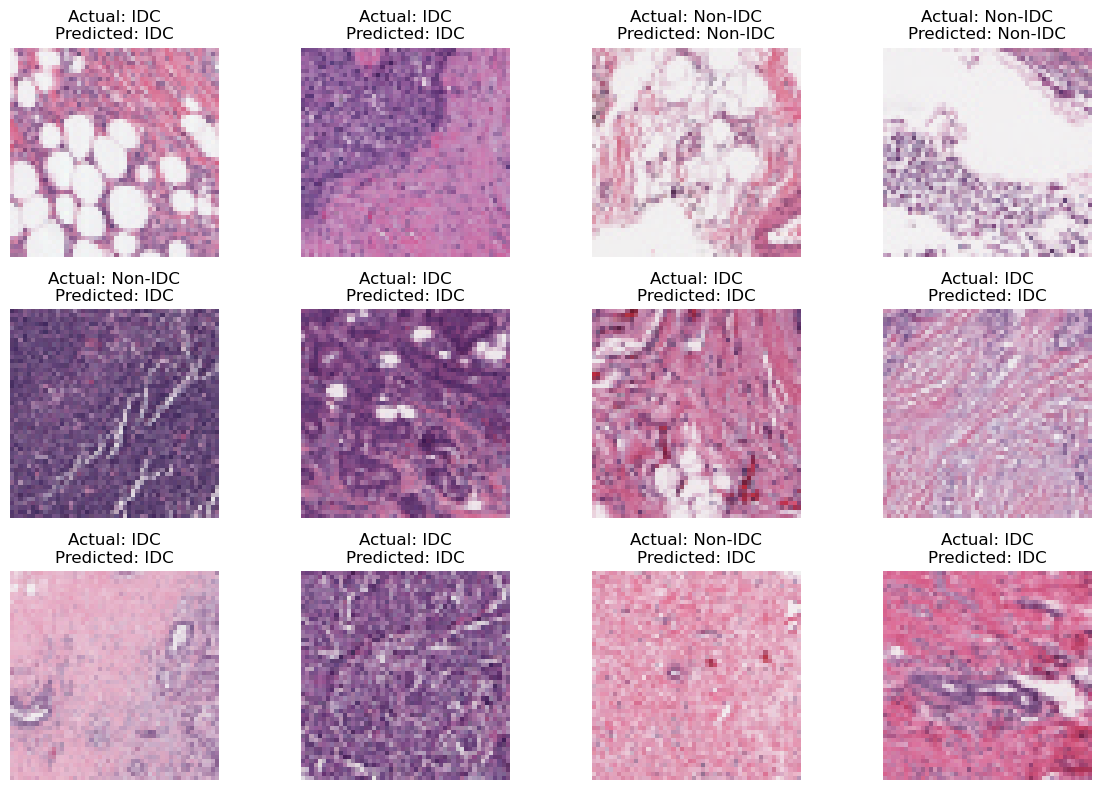

In [45]:
# Display test images with actual and predicted labels

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])

    actual_label = "IDC" if y_test[i] == 1 else "Non-IDC"
    predicted_label = "IDC" if y_pred[i] == 1 else "Non-IDC"

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
# Find incorrectly classified test images

incorrect_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 70


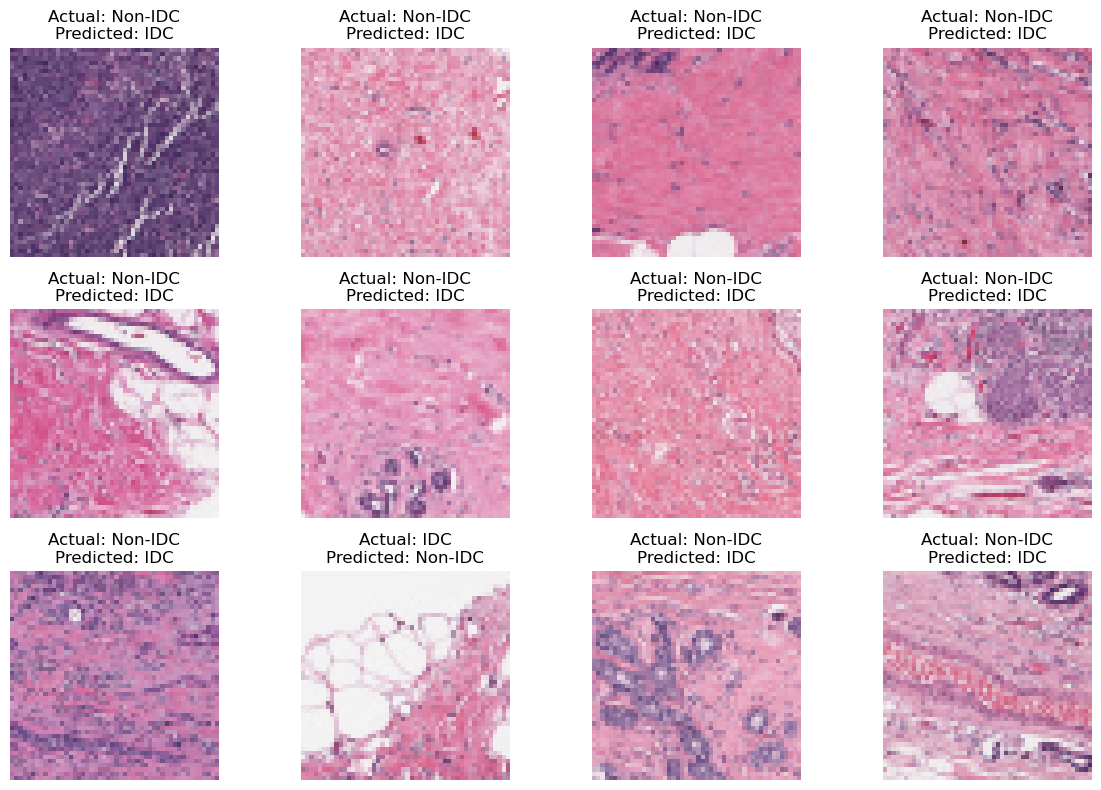

In [47]:
# Display incorrectly classified test images

num_images = min(12, len(incorrect_indices))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    index = incorrect_indices[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    actual_label = "IDC" if y_test[index] == 1 else "Non-IDC"
    predicted_label = "IDC" if y_pred[index] == 1 else "Non-IDC"

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
# Import ROC and AUC functions

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob.ravel()
)

roc_auc = auc(fpr, tpr)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8669


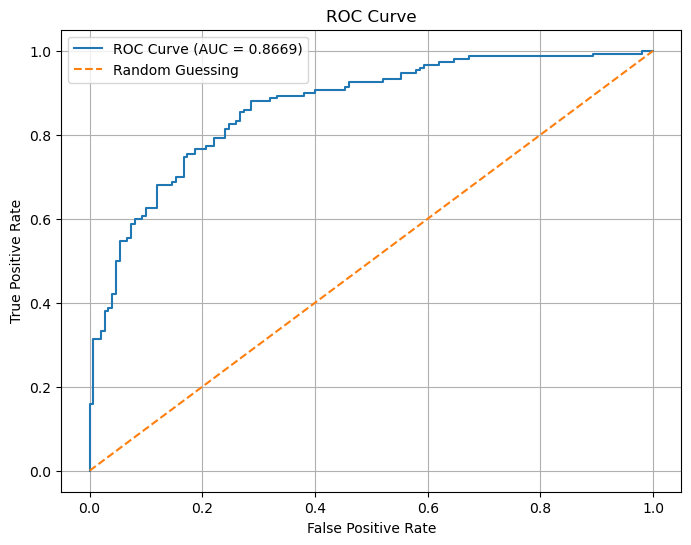

In [52]:
# Plot the ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
# Count correct and incorrect predictions

correct_predictions = np.sum(y_test == y_pred)
incorrect_predictions = np.sum(y_test != y_pred)

print("Total test images:", len(y_test))
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

Total test images: 300
Correct predictions: 230
Incorrect predictions: 70


In [54]:
# Create a summary of the final CNN performance

results = {
    "Metric": [
        "Test Accuracy",
        "Precision (IDC)",
        "Recall (IDC)",
        "F1-score (IDC)",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
}

results_df = pd.DataFrame(results)

# Convert scores to percentages
results_df["Score (%)"] = results_df["Score"] * 100

print(results_df.to_string(index=False))

         Metric    Score  Score (%)
  Test Accuracy 0.766667  76.666667
Precision (IDC) 0.712766  71.276596
   Recall (IDC) 0.893333  89.333333
 F1-score (IDC) 0.792899  79.289941
        ROC-AUC 0.866933  86.693333


In [55]:
# Extract confusion matrix values

tn, fp, fn, tp = cm.ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 96
False Positives (FP): 54
False Negatives (FN): 16
True Positives (TP): 134


# Final project conclusion

1. We developed a Convolutional Neural Network (CNN) for
   classifying breast tissue images into Non-IDC and IDC.

2. We used a balanced dataset of 2,000 images:
   - 1,000 Non-IDC
   - 1,000 IDC

3. The data was divided into:
   - 1,400 training images
   - 300 validation images
   - 300 testing images

4. The CNN was trained using data augmentation and evaluated
   on previously unseen test images.

5. The final test accuracy was 76.67%.

6. For the IDC class:
   - Precision: 71.28%
   - Recall: 89.33%
   - F1-score: 79.29%

7. The ROC-AUC was 86.69%, indicating good ability to
   distinguish between IDC and Non-IDC in this experiment.

8. The model correctly classified 230 of the 300 test images.

